In [12]:
# ============================================
# 0) Reproducibilidad y Entorno Python
# ============================================

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)
os.environ["PYTHONHASHSEED"] = str(RANDOM_SEED)

print(
    f"Python: {sys.version.split()[0]} | "
    f"NumPy: {np.__version__} | "
    f"Pandas: {pd.__version__} | "
    f"scikit-learn: {sklearn.__version__} | "
    f"OS: {platform.system()}-{platform.release()} | "
    f"PYTHONHASHSEED: {os.environ['PYTHONHASHSEED']}"
)

Python: 3.12.12 | NumPy: 2.0.2 | Pandas: 2.2.2 | scikit-learn: 1.6.1 | OS: Linux-6.6.113+ | PYTHONHASHSEED: 42


In [13]:
# ============================================
# 1) Librerias
# ============================================

import os, sys, platform, random
import numpy as np
import pandas as pd
import sklearn
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')

In [14]:

# ============================================
# 2) Carga de datos
# ============================================
# Ajusta el nombre si cambias el archivo
file_path = '/content/SPE_shale_original - copia.xlsx'

# Si el libro tiene una sola hoja o la hoja se llama distinto, ajusta sheet_name
df = pd.read_excel(file_path, sheet_name=0, engine='openpyxl')

print('Dimensiones iniciales:', df.shape)
df.head()


Dimensiones iniciales: (50, 26)


,Lease,Well Number,State,Formation,Initial Pressure Estimate (psi),Reservoir Temperature (deg F),Net Pay (ft),Porosity,Water Saturation,Oil Saturation,...,# Stages,# Clusters,# Clusters per Stage,# of Total Proppant (MM Lbs),Lateral Length (ft),Top Perf (ft),Bottom Perf (ft),Sandface Temp (deg F),Static Wellhead Temp (deg F),"Cumulative Gas Produced after 1 year, MCF"
0,OSPREY,1,TX,EAGLE_FORD,5400,225,78,0.0630,0.2600,0.7400,...,28,252,9.0000,13.5145,5883,8030,13913,225.0000,70.0000,25.1260
1,EAGLE,4,TX,EAGLE_FORD,5000,235,74,0.0630,0.2700,0.7300,...,50,450,9.0000,25.2674,7481,7958,15439,234.0000,60.0000,74.4577
2,KITE,5,TX,EAGLE_FORD,5000,238,56,0.0500,0.3210,0.6790,...,34,306,9.0000,18.5548,5086,9388,14474,235.0000,65.0000,46.2181
3,SWIFT,6,TX,EAGLE_FORD,5164,225,63,0.0520,0.3310,0.6690,...,50,450,9.0000,27.7856,7479,8657,16136,225.0000,70.0000,73.9936
4,SPARROW,7,TX,EAGLE_FORD,5164,225,62,0.0520,0.3320,0.6680,...,49,441,9.0000,27.5507,7346,8683,16029,225.0000,70.0000,74.6704


In [15]:
# Diccionario de Variables
# =========================================================
data_dictionary = [
    # idx, nombre_original, unidad, descripcion
    (1,  "Lease", "Empresa Operadora ", "Nombre del lease / operador"),
    (2,  "Well Number", "Número del pozo", "Identificador del pozo"),
    (3,  "State", "Ubicación geográfica", "Estado"),
    (4,  "Formation", "Formación productiva (play)", "Formación o play"),
    (5,  "Initial Pressure Estimate (psi)", "psi", "Presión inicial estimada"),
    (6,  "Reservoir Temperature (deg F)", "deg F", "Temperatura de yacimiento"),
    (7,  "Net Pay (ft)", "ft", "Espesor neto productivo"),
    (8,  "Porosity", "fracción", "Porosidad"),
    (9,  "Water Saturation", "fracción", "Saturación de agua"),
    (10, "Oil Saturation", "fracción", "Saturación de aceite"),
    (11, "Gas Saturation", "fracción", "Saturación de gas"),
    (12, "Gas Specific Gravity", "Adimiensional", "Gravedad específica del gas"),
    (13, "CO2", "fracción", "Fracción molar CO2"),
    (14, "N2", "fracción", "Fracción molar N2"),
    (15, "TVD (ft)", "ft", "True Vertical Depth (profundidad vertical)"),
    (16, "Spacing", "ft", "Espaciamiento de pozos"),
    (17, "# Stages", "Conteo de etapas", "Número de etapas de fractura"),
    (18, "# Clusters", "Conteo de Clusters", "Número de clústeres"),
    (19, "# Clusters per Stage", "clústeres/etapas", "Clústeres por etapa"),
    (20, "# of Total Proppant (MM Lbs)", "MM Lbs", "Proppant total"),
    (21, "Lateral Length (ft)", "ft", "Longitud lateral"),
    (22, "Top Perf (ft)", "ft", "Profundidad perforada superior"),
    (23, "Bottom Perf (ft)", "ft", "Profundidad perforada inferior"),
    (24, "Sandface Temp (deg F)", "deg F", "Temperatura en cara de arena"),
    (25, "Static Wellhead Temp (deg F)", "deg F", "Temperatura en cabeza estática"),
    (26, "Cumulative Gas Produced after 1 year, MCF", "MCF", "Gas acumulado a 1 año"),
]


In [16]:

# ============================================
# 3) Estandarización de nombres de columnas
#    - quita espacios, convierte a snake_case y corrige caracteres especiales
# ============================================
def to_snake(s):
    s = (s.strip()
         .replace('\n', ' ')
         .replace('(', '')
         .replace(')', '')
         .replace('%', 'pct')
         .replace('#', 'num')
         .replace('-', '_'))
    s = ' '.join(s.split())
    s = s.lower().replace(' ', '_').replace('__','_')
    return s

df.columns = [to_snake(c) for c in df.columns]
df.columns


Index(['lease', 'well_number', 'state', 'formation',
       'initial_pressure_estimate_psi', 'reservoir_temperature_deg_f',
       'net_pay_ft', 'porosity', 'water_saturation', 'oil_saturation',
       'gas_saturation', 'gas_specific_gravity', 'co2', 'n2', 'tvd_ft',
       'spacing', 'num_stages', 'num_clusters', 'num_clusters_per_stage',
       'num_of_total_proppant_mm_lbs', 'lateral_length_ft', 'top_perf_ft',
       'bottom_perf_ft', 'sandface_temp_deg_f', 'static_wellhead_temp_deg_f',
       'cumulative_gas_produced_after_1_year,_mcf'],
      dtype='object')

In [17]:

# ============================================
# 4) Tipos de datos y conversión
#    - Detecta numéricos con errores (texto numérico) y los convierte
# ============================================
for col in df.columns:
    if df[col].dtype == 'object':
        # intenta convertir strings a número si procede (mantiene texto si no aplica)
        conv = pd.to_numeric(df[col].astype(str).str.replace(',', ''), errors='ignore')
        # Si la conversión funcionó parcialmente, reasigna (cuando resultó numeric)
        if np.issubdtype(conv.dtype, np.number):
            df[col] = conv

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 26 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   lease                                      50 non-null     object 
 1   well_number                                50 non-null     int64  
 2   state                                      50 non-null     object 
 3   formation                                  50 non-null     object 
 4   initial_pressure_estimate_psi              50 non-null     int64  
 5   reservoir_temperature_deg_f                50 non-null     int64  
 6   net_pay_ft                                 50 non-null     int64  
 7   porosity                                   50 non-null     float64
 8   water_saturation                           50 non-null     float64
 9   oil_saturation                             50 non-null     float64
 10  gas_saturation              

/tmp/ipykernel_565/4259995271.py:8: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  conv = pd.to_numeric(df[col].astype(str).str.replace(',', ''), errors='ignore')
/tmp/ipykernel_565/4259995271.py:8: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  conv = pd.to_numeric(df[col].astype(str).str.replace(',', ''), errors='ignore')
/tmp/ipykernel_565/4259995271.py:8: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  conv = pd.to_numeric(df[col].astype(str).str.replace(',', ''), errors='ignore')


In [18]:
# ============================================
# 5) valores faltantes y Duplicados
# ============================================
dup_count = df.duplicated().sum()
# if dup_count > 0:
    # df = df.drop_duplicates()
print(f'Duplicados encontrados (no eliminados): {dup_count}')
print('Valores faltantes por columna:')
print(df.isna().sum().sort_values(ascending=False))

# Opcional: imputaciones simples para numéricos (mediana) y categóricos (moda)
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()

df[num_cols] = df[num_cols].fillna(df[num_cols].median())
for c in cat_cols:
    if df[c].isna().any():
        df[c] = df[c].fillna(df[c].mode().iloc[0])

print('\nFaltantes post-imputación:')
print(df.isna().sum().sum())

Duplicados encontrados (no eliminados): 0
Valores faltantes por columna:
lease                                        0
well_number                                  0
state                                        0
formation                                    0
initial_pressure_estimate_psi                0
reservoir_temperature_deg_f                  0
net_pay_ft                                   0
porosity                                     0
water_saturation                             0
oil_saturation                               0
gas_saturation                               0
gas_specific_gravity                         0
co2                                          0
n2                                           0
tvd_ft                                       0
spacing                                      0
num_stages                                   0
num_clusters                                 0
num_clusters_per_stage                       0
num_of_total_proppant_mm_lbs      

In [19]:
# 5.1 Eliminación de filas con valores cero en columnas específicas

#  eliminar las filas del DataFrame `df` donde las columnas `'oil_saturation'`, `'co2'` o `'n2'`
#contengan un valor de cero, ya que estos valores podrían ser atípicos o representar datos faltantes no declarados.

initial_rows = df.shape[0]

# Define las columnas para las que se eliminarán las filas con valor cero
# Filter columns_to_check to only include those present in the DataFrame
original_columns_to_check = ['oil_saturation', 'co2', 'n2']
columns_to_check = [col for col in original_columns_to_check if col in df.columns]

if columns_to_check: # Only proceed if there are columns to check
    # Crea una condición booleana para identificar las filas que contienen cero en cualquiera de las columnas especificadas
    # Utilizamos `~` para negar la condición, quedándonos con las filas que NO tienen cero en esas columnas
    condition = (df[columns_to_check] == 0).any(axis=1)
    df_filtered = df[~condition]

    # Imprime el número de filas eliminadas y las dimensiones del DataFrame resultante
    rows_removed = initial_rows - df_filtered.shape[0]
    print(f"Filas iniciales: {initial_rows}")
    print(f"Filas eliminadas donde {', '.join(columns_to_check)} eran cero: {rows_removed}")
    print(f"Filas restantes: {df_filtered.shape[0]}")
else:
    print(f"No hay columnas '{', '.join(original_columns_to_check)}' presentes en el DataFrame para verificar valores cero.")
    df_filtered = df.copy() # Ensure df_filtered is defined even if no columns to check

# df = df_filtered.copy() # Comentado para mantener todos los datos

display(df.head())

Filas iniciales: 50
Filas eliminadas donde oil_saturation, co2, n2 eran cero: 48
Filas restantes: 2


,lease,well_number,state,formation,initial_pressure_estimate_psi,reservoir_temperature_deg_f,net_pay_ft,porosity,water_saturation,oil_saturation,...,num_stages,num_clusters,num_clusters_per_stage,num_of_total_proppant_mm_lbs,lateral_length_ft,top_perf_ft,bottom_perf_ft,sandface_temp_deg_f,static_wellhead_temp_deg_f,"cumulative_gas_produced_after_1_year,_mcf"
0,OSPREY,1,TX,EAGLE_FORD,5400,225,78,0.0630,0.2600,0.7400,...,28,252,9.0000,13.5145,5883,8030,13913,225.0000,70.0000,25.1260
1,EAGLE,4,TX,EAGLE_FORD,5000,235,74,0.0630,0.2700,0.7300,...,50,450,9.0000,25.2674,7481,7958,15439,234.0000,60.0000,74.4577
2,KITE,5,TX,EAGLE_FORD,5000,238,56,0.0500,0.3210,0.6790,...,34,306,9.0000,18.5548,5086,9388,14474,235.0000,65.0000,46.2181
3,SWIFT,6,TX,EAGLE_FORD,5164,225,63,0.0520,0.3310,0.6690,...,50,450,9.0000,27.7856,7479,8657,16136,225.0000,70.0000,73.9936
4,SPARROW,7,TX,EAGLE_FORD,5164,225,62,0.0520,0.3320,0.6680,...,49,441,9.0000,27.5507,7346,8683,16029,225.0000,70.0000,74.6704


In [20]:

# ============================================
# 6) Reglas de validación básicas (dominios físicos)
#    - Ajusta a tu criterio: saturaciones entre 0-1, porosidad 0-1, etc.
# ============================================
# columnas candidatas (si existen en el dataset)
bounds = {
    'porosity': (0, 1),
    'water_saturation': (0, 1),
    'oil_saturation': (0, 1),
    'gas_saturation': (0, 1),
    'gas_specific_gravity': (0, 2), # típico 0.55-0.8 aprox; dejamos 0-2 como rango laxo
    'initial_pressure_estimate_psi': (0, None),
    'reservoir_temperature_deg_f': (0, None),
    'net_pay_ft': (0, None),
    'tvd_ft': (0, None),
    'lateral_length_ft': (0, None),
    'sandface_temp_deg_f': (0, None),
    'static_wellhead_temp_deg_f': (0, None),
    'cumulative_gas_produced_after_1_year_mcf': (0, None)
}

for col, (low, high) in bounds.items():
    if col in df.columns:
        if low is not None:
            df.loc[df[col] < low, col] = np.nan
        if high is not None:
            df.loc[df[col] > high, col] = np.nan

# Reimputación tras reglas
df[num_cols] = df[num_cols].fillna(df[num_cols].median())


In [21]:
column_to_drop_snake = 'oil_saturation'
column_to_drop_original = ' Oil Saturation ' # Basado en el displayData de la ejecución anterior

if column_to_drop_snake in df.columns:
    df = df.drop(columns=[column_to_drop_snake])
    print(f"La columna '{column_to_drop_snake}' ha sido eliminada.")
elif column_to_drop_original in df.columns:
    df = df.drop(columns=[column_to_drop_original])
    print(f"La columna '{column_to_drop_original}' ha sido eliminada.")
else:
    print("La columna 'oil_saturation' o ' Oil Saturation ' no se encuentra en el DataFrame.")

display(df.head())

La columna 'oil_saturation' ha sido eliminada.


,lease,well_number,state,formation,initial_pressure_estimate_psi,reservoir_temperature_deg_f,net_pay_ft,porosity,water_saturation,gas_saturation,...,num_stages,num_clusters,num_clusters_per_stage,num_of_total_proppant_mm_lbs,lateral_length_ft,top_perf_ft,bottom_perf_ft,sandface_temp_deg_f,static_wellhead_temp_deg_f,"cumulative_gas_produced_after_1_year,_mcf"
0,OSPREY,1,TX,EAGLE_FORD,"5,400.0000",225.0000,78.0000,0.0630,0.2600,0.0000,...,28,252,9.0000,13.5145,"5,883.0000",8030,13913,225.0000,70.0000,25.1260
1,EAGLE,4,TX,EAGLE_FORD,"5,000.0000",235.0000,74.0000,0.0630,0.2700,0.0000,...,50,450,9.0000,25.2674,"7,481.0000",7958,15439,234.0000,60.0000,74.4577
2,KITE,5,TX,EAGLE_FORD,"5,000.0000",238.0000,56.0000,0.0500,0.3210,0.0000,...,34,306,9.0000,18.5548,"5,086.0000",9388,14474,235.0000,65.0000,46.2181
3,SWIFT,6,TX,EAGLE_FORD,"5,164.0000",225.0000,63.0000,0.0520,0.3310,0.0000,...,50,450,9.0000,27.7856,"7,479.0000",8657,16136,225.0000,70.0000,73.9936
4,SPARROW,7,TX,EAGLE_FORD,"5,164.0000",225.0000,62.0000,0.0520,0.3320,0.0000,...,49,441,9.0000,27.5507,"7,346.0000",8683,16029,225.0000,70.0000,74.6704


In [22]:

# ============================================
# 7) Detección y tratamiento de outliers (IQR) en numéricos
#    - Capado por percentil 1 y 99 + winsorización por IQR
# ============================================
def winsorize_iqr(series, k=1.5):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    low = q1 - k * iqr
    high = q3 + k * iqr
    return series.clip(lower=low, upper=high)

# Re-define num_cols to reflect current DataFrame columns after 'oil_saturation' might have been dropped
num_cols = df.select_dtypes(include=np.number).columns.tolist()

# Primero capado duro en p01-p99
p01 = df[num_cols].quantile(0.01)
p99 = df[num_cols].quantile(0.99)
df[num_cols] = df[num_cols].clip(lower=p01, upper=p99, axis=1);

# Luego winsorización por IQR
for c in num_cols:
    df[c] = winsorize_iqr(df[c])

print('Limpieza de outliers completada.')


Limpieza de outliers completada.


In [23]:

# ============================================
# 8) Estadísticas descriptivas
# ============================================
print('\nEstadísticas descriptivas (numéricos):')
display(df[num_cols].describe().T)

# Frecuencias de categóricos
for c in cat_cols:
    print(f'\nFrecuencias de {c}:')
    display(df[c].value_counts(dropna=False).to_frame('conteo'))



Estadísticas descriptivas (numéricos):


,count,mean,std,min,25%,50%,75%,max
well_number,50.0000,41.1596,22.0954,2.4700,27.2500,39.5000,63.7500,75.5100
initial_pressure_estimate_psi,50.0000,"6,307.9196","2,942.0661","2,347.0000","4,300.0000","5,164.0000","9,929.2500","11,782.9800"
reservoir_temperature_deg_f,50.0000,211.2580,93.3300,119.9000,134.0000,144.5000,323.0000,379.0000
net_pay_ft,50.0000,163.2232,56.2920,58.9400,136.0000,164.5000,208.7500,257.2200
porosity,50.0000,0.0705,0.0132,0.0510,0.0603,0.0685,0.0839,0.0956
water_saturation,50.0000,0.3011,0.0874,0.1872,0.2100,0.3101,0.3625,0.4700
gas_saturation,50.0000,0.6309,0.1881,0.2507,0.5743,0.6765,0.7900,0.8128
gas_specific_gravity,50.0000,0.5866,0.0228,0.5700,0.5700,0.5700,0.5948,0.6319
co2,50.0000,0.0115,0.0178,0.0000,0.0000,0.0000,0.0246,0.0541
n2,50.0000,0.0002,0.0003,0.0000,0.0000,0.0000,0.0004,0.0010



Frecuencias de lease:


,conteo
lease,
OSPREY,1
EAGLE,1
KITE,1
SWIFT,1
SPARROW,1
LARK,1
CARDINAL,1
JAY,1
LORIKEET,1



Frecuencias de state:


,conteo
state,
PA,27
LA,15
TX,8



Frecuencias de formation:


,conteo
formation,
MARCELLUS_UPPER,16
HAYNESVILLE_SHALE,14
MARCELLUS,11
EAGLE_FORD,8
BOSSIER_SHALE,1


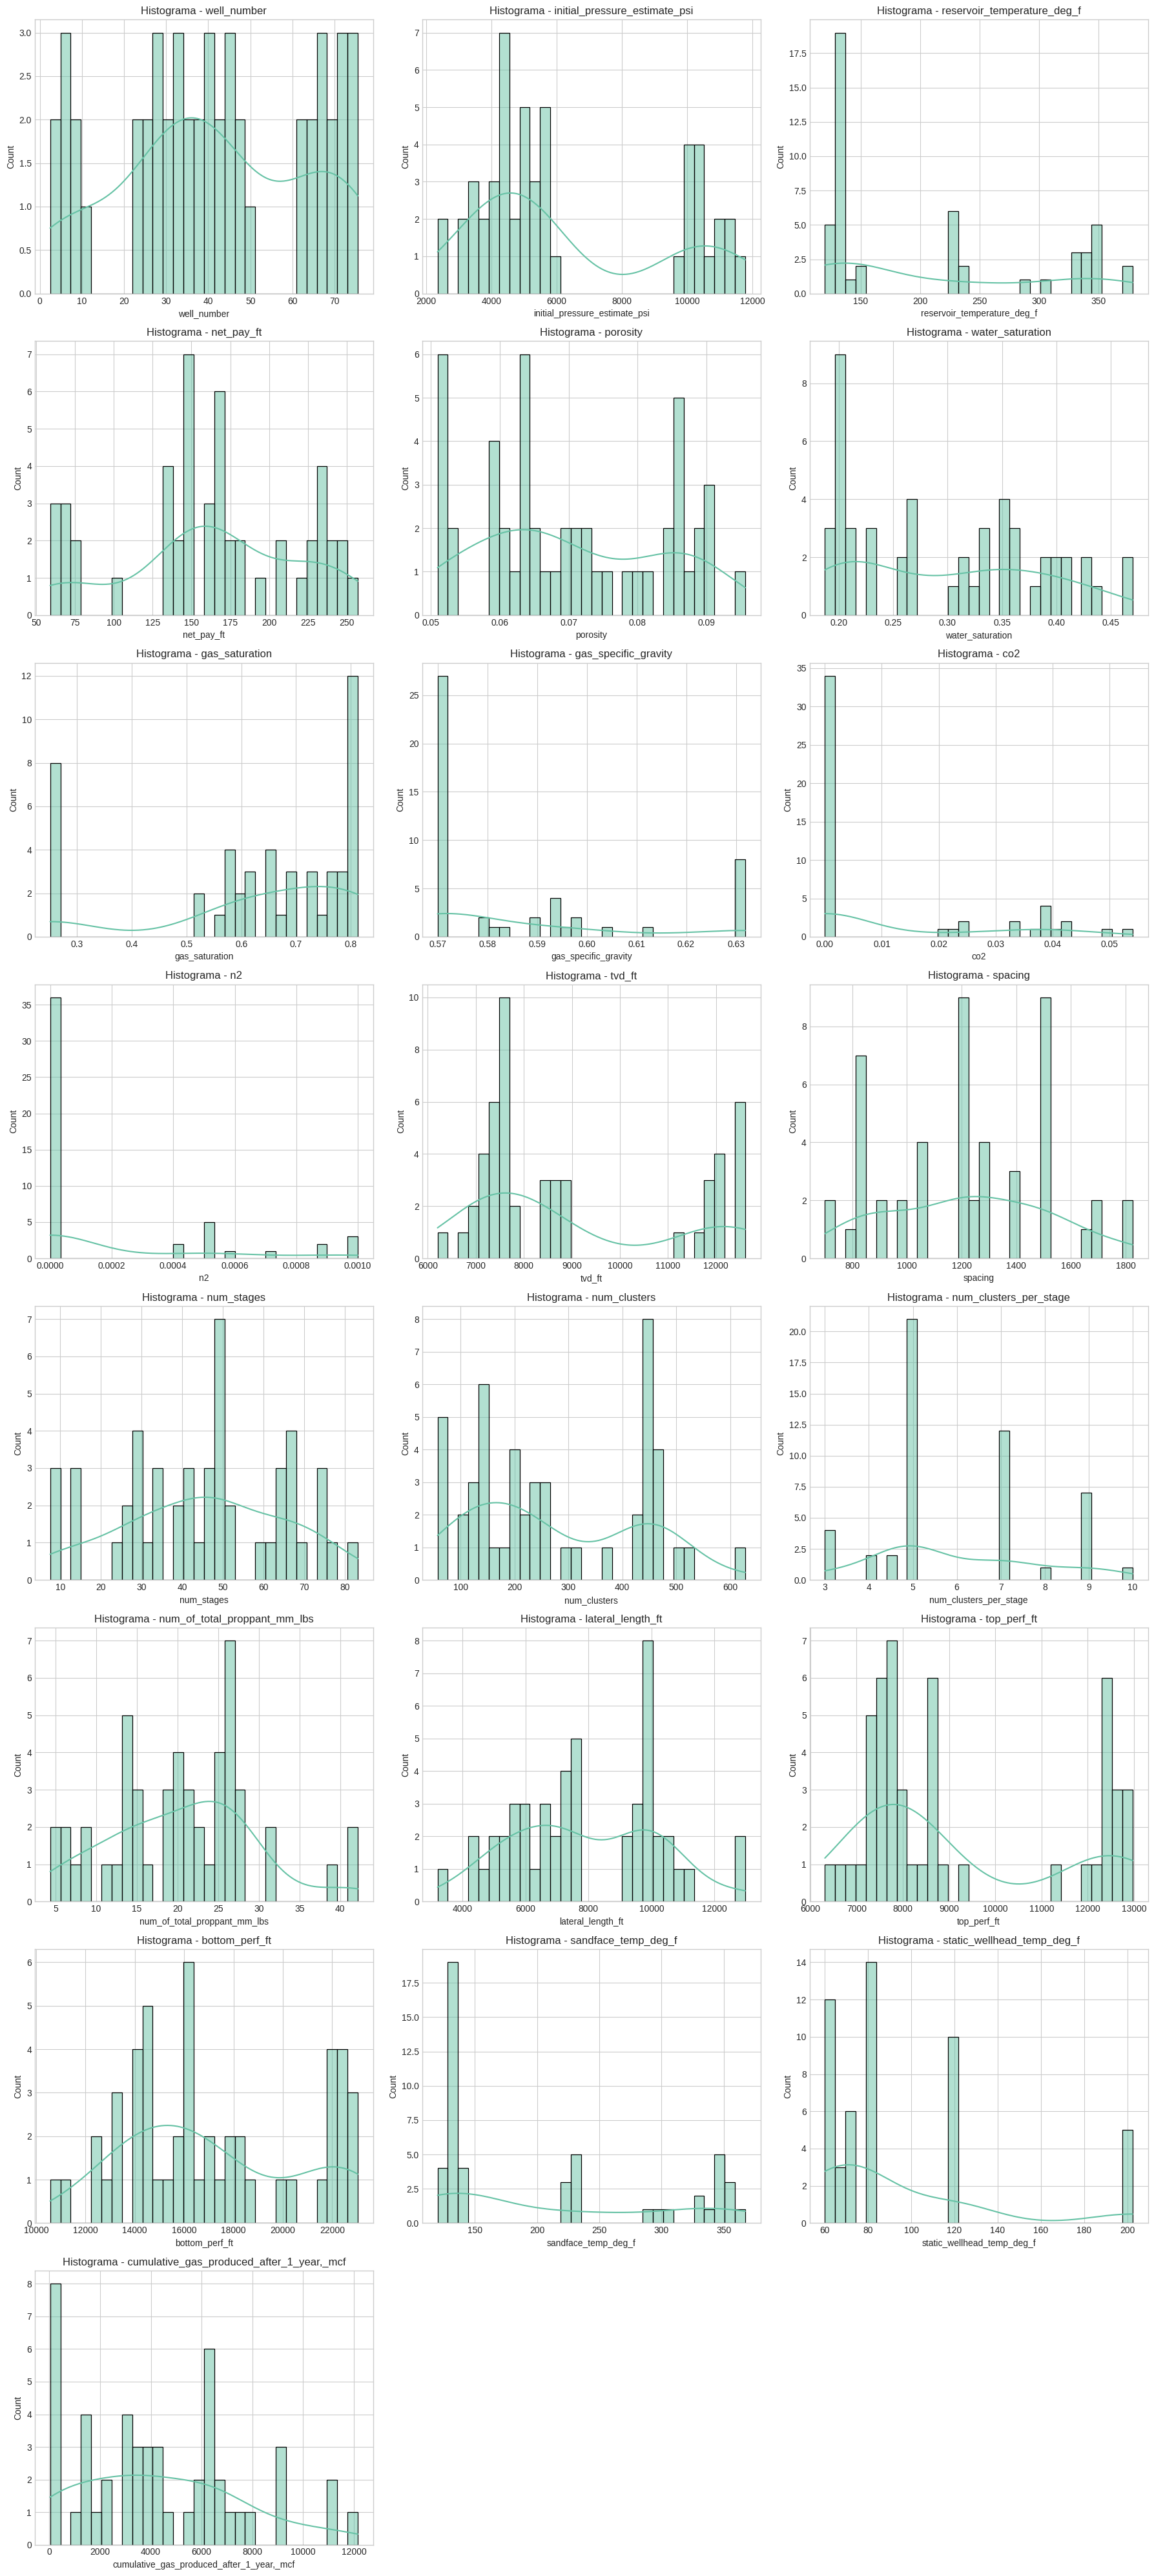

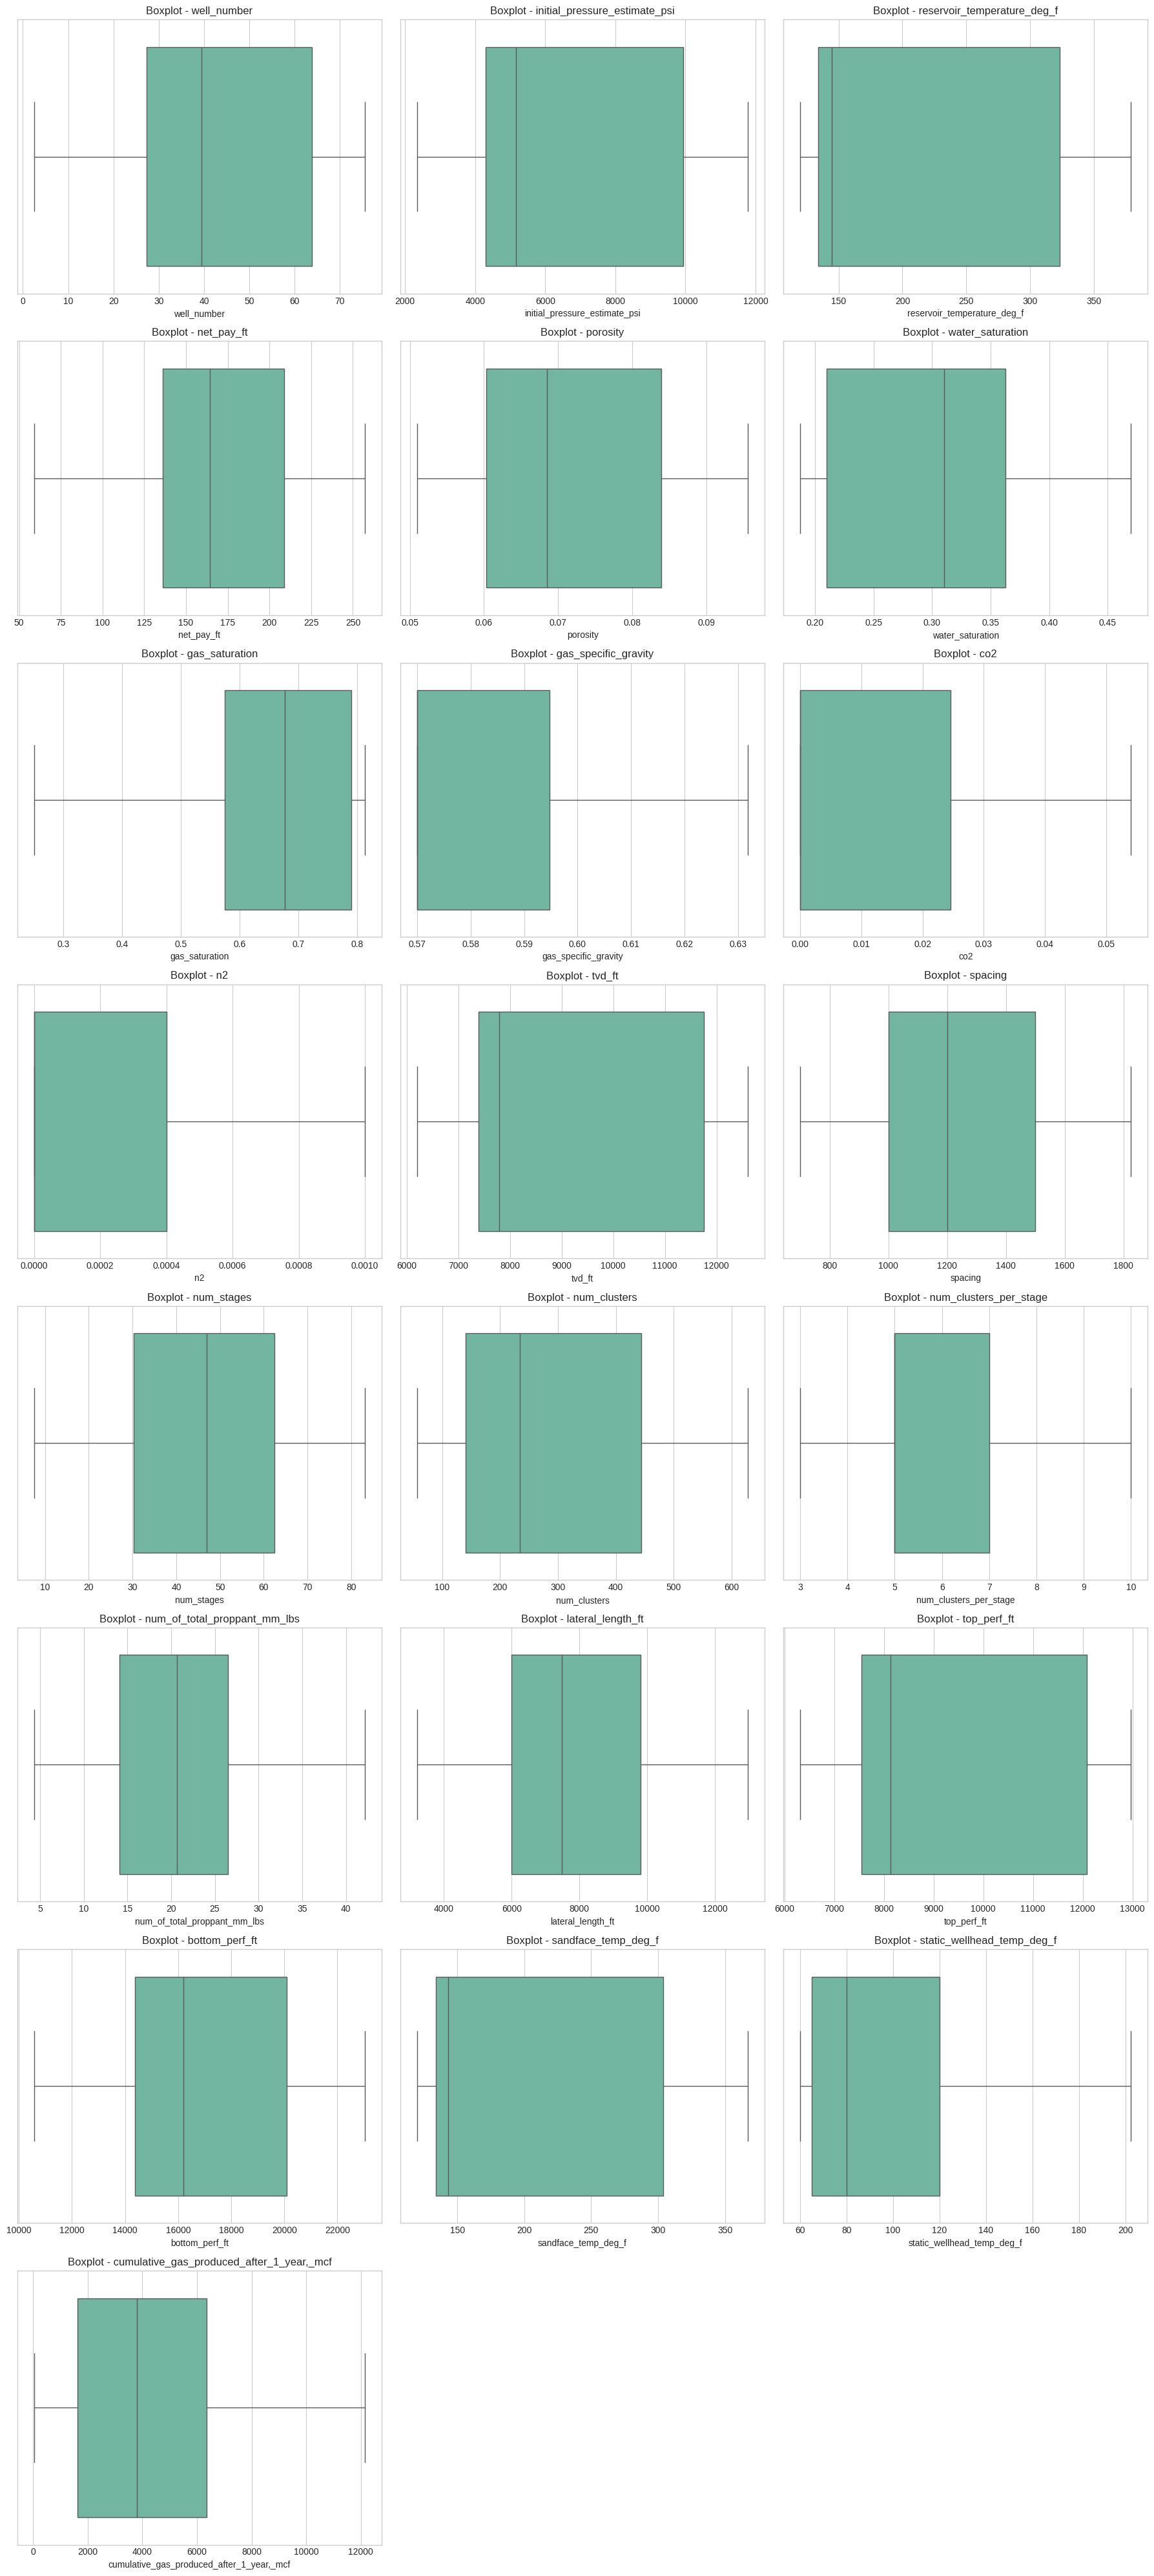

In [24]:
# ============================================
# 9) Visualizaciones: Histogramas y Boxplots (numéricos)
# ============================================
n = len(num_cols)
cols = 3
rows = int(np.ceil(n / cols))

# Obtener el color exacto de la primera entrada de la paleta 'Set2'
default_green_color = sns.color_palette('Set2')[0]

plt.figure(figsize=(18, 5*rows))
for i, c in enumerate(num_cols, 1):
    plt.subplot(rows, cols, i)
    sns.histplot(df[c], kde=True, bins=30, color=default_green_color)
    plt.title(f'Histograma - {c}')
plt.tight_layout()
plt.show()

plt.figure(figsize=(18, 5*rows))
for i, c in enumerate(num_cols, 1):
    plt.subplot(rows, cols, i)
    sns.boxplot(x=df[c], color=default_green_color)
    plt.title(f'Boxplot - {c}')
plt.tight_layout()
plt.show()

```markdown
# 10) Correlaciones Numéricas
```

In [25]:
# Calcular la matriz de correlación para columnas numéricas, excluyendo 'oil_saturation'
num_cols = df.select_dtypes(include=np.number).columns.tolist()
# Es crucial identificar correctamente el nombre original de la columna si la conversión a snake_case no persistió para corr_matrix
# Basado en el error, corr_matrix fue generada con los nombres originales.
# Asegurémonos de que 'oil_saturation' sea excluido independientemente de su caso
original_oil_saturation_name = 'Oil Saturation'
snake_case_oil_saturation_name = 'oil_saturation'

# Priorizar snake_case si está presente, de lo contrario, usar el nombre original
actual_oil_saturation_to_exclude = None
if snake_case_oil_saturation_name in num_cols:
    actual_oil_saturation_to_exclude = snake_case_oil_saturation_name
elif original_oil_saturation_name in num_cols:
    actual_oil_saturation_to_exclude = original_oil_saturation_name

if actual_oil_saturation_to_exclude:
    num_cols_for_corr = [col for col in num_cols if col != actual_oil_saturation_to_exclude]
else:
    num_cols_for_corr = num_cols

corr_matrix = df[num_cols_for_corr].corr()

# Mostrar las correlaciones con la variable objetivo
# Basado en errores previos, la matriz de correlación probablemente usa los nombres de columna originales para indexación.
# La variable objetivo era 'Cumulative Gas Produced after 1 year, MCF' antes de la conversión a snake_case.
# Usemos ese nombre para acceder a la corr_matrix.
original_target_name = 'Cumulative Gas Produced, MCF'
snake_case_target_name = 'cumulative_gas_produced,_mcf'

target_variable_to_use = None
if snake_case_target_name in corr_matrix.columns:
    target_variable_to_use = snake_case_target_name
elif original_target_name in corr_matrix.columns:
    target_variable_to_use = original_target_name

if target_variable_to_use:
    print(f"\nCorrelaciones con la variable objetivo '{target_variable_to_use}':")
    display(corr_matrix[target_variable_to_use].sort_values(ascending=False).to_frame('Correlación'))
#else:
    #print(f"Error: La variable objetivo '{snake_case_target_name}' o '{original_target_name}' no se encontró en la matriz de correlación. Columnas disponibles: {corr_matrix.columns.tolist()}")





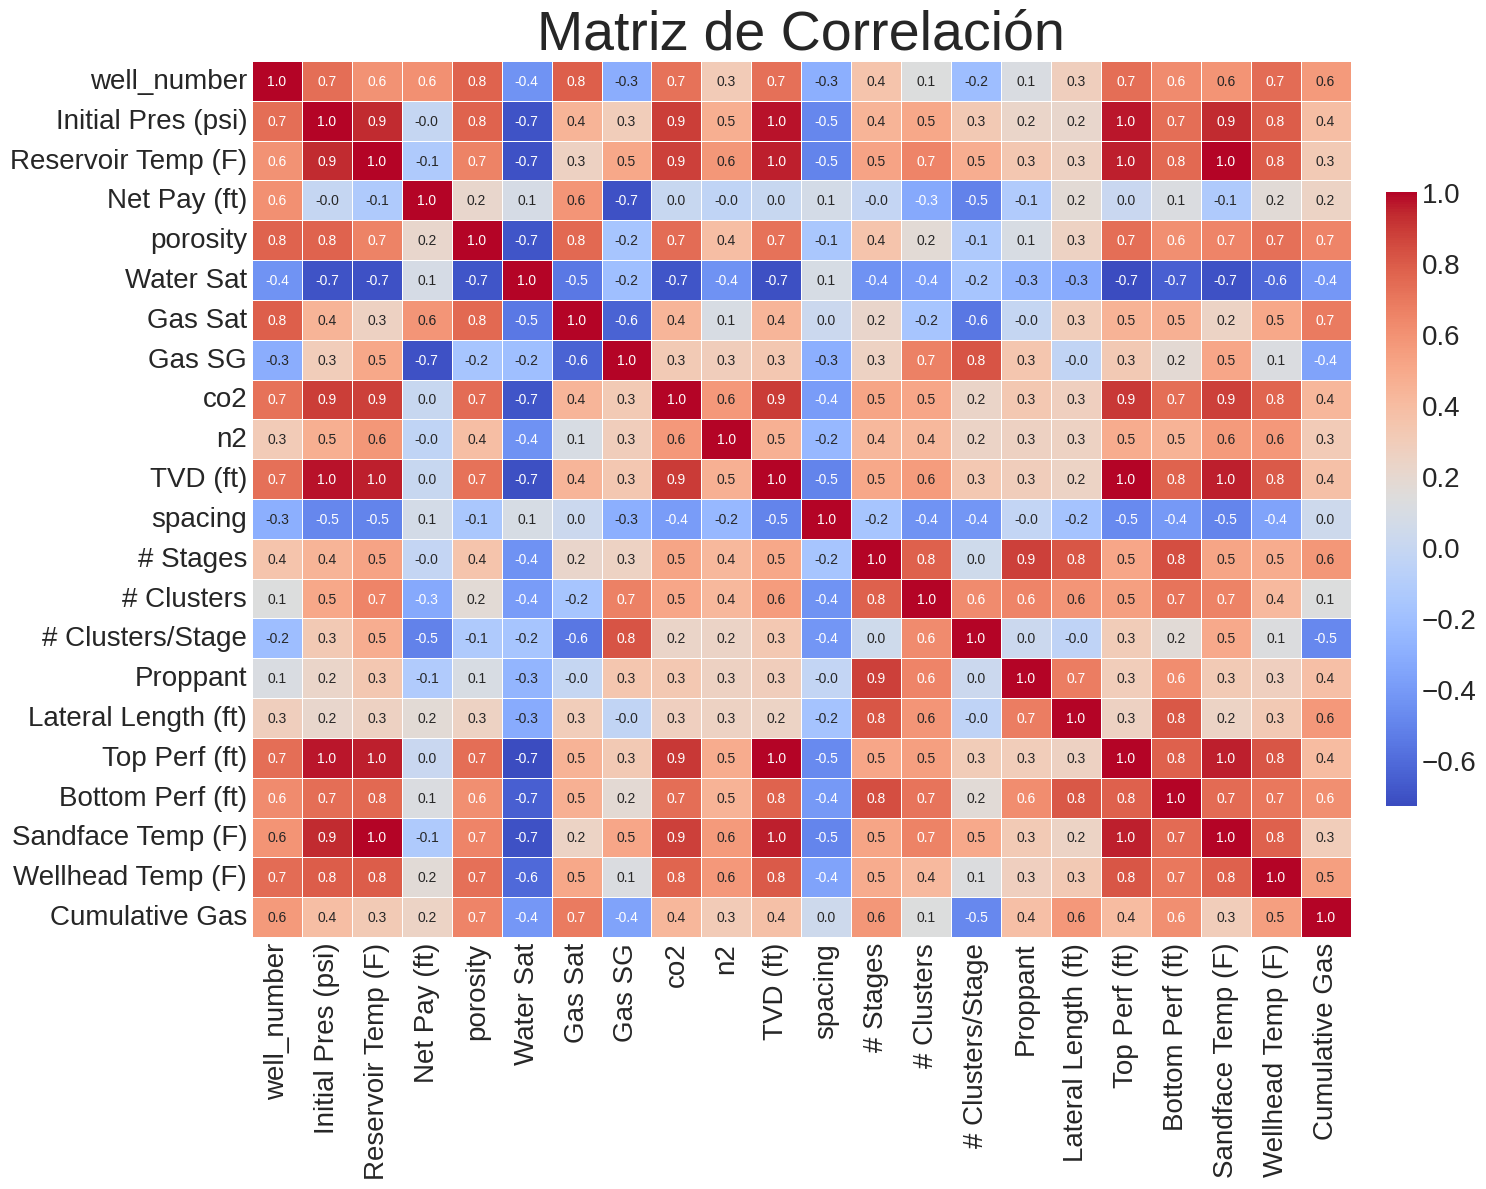

In [26]:
fig_w = 15
fig_h = 12

# Crear una copia de corr_matrix para propósitos de visualización
corr_matrix_display = corr_matrix.copy()

# Definir el nombre original y el nuevo nombre para la variable objetivo
old_target_col = 'cumulative_gas_produced_after_1_year,_mcf'
new_target_col_display = 'Cumulative Gas'

# Crear un diccionario de mapeo para nombres de columnas más cortos
display_name_map = {
    'initial_pressure_estimate_psi': 'Initial Pres (psi)',
    'reservoir_temperature_deg_f': 'Reservoir Temp (F)',
    'net_pay_ft': 'Net Pay (ft)',
    'water_saturation': 'Water Sat',
    'oil_saturation': 'Oil Sat',
    'gas_saturation': 'Gas Sat',
    'gas_specific_gravity': 'Gas SG',
    'tvd_ft': 'TVD (ft)',
    'num_stages': '# Stages',
    'num_clusters': '# Clusters',
    'num_clusters_per_stage': '# Clusters/Stage',
    'num_of_total_proppant_mm_lbs': 'Proppant',
    'lateral_length_ft': 'Lateral Length (ft)',
    'top_perf_ft': 'Top Perf (ft)',
    'bottom_perf_ft': 'Bottom Perf (ft)',
    'sandface_temp_deg_f': 'Sandface Temp (F)',
    'static_wellhead_temp_deg_f': 'Wellhead Temp (F)',
    old_target_col: new_target_col_display # Mapeo para la variable objetivo
}

# Renombrar las columnas y el índice en la copia para la visualización
corr_matrix_display = corr_matrix_display.rename(
    columns=display_name_map,
    index=display_name_map
)

plt.figure(figsize=(fig_w, fig_h))
ax = sns.heatmap(
    corr_matrix_display, # Usar la matriz con el nombre de columna modificado para display
    annot=True,
    cmap='coolwarm',
    fmt=".1f",
    linewidths=.5,
    cbar_kws={
        'shrink': 0.7,
        'aspect': 20,
        'fraction': 0.05,
        'pad': 0.03
    }
)
plt.title('Matriz de Correlación', fontsize=40)

# Ajustar el tamaño de los números en los ejes
plt.xticks(fontsize=20) # Aumentado el tamaño de fuente
plt.yticks(fontsize=20) # Aumentado el tamaño de fuente

# Obtener el colorbar y cambiar tamaño de los números
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=20)


plt.tight_layout()
plt.show()


Top variables correlacionadas con el target:
cumulative_gas_produced_after_1_year,_mcf   1.0000
gas_saturation                              0.6843
porosity                                    0.6550
bottom_perf_ft                              0.6101
num_stages                                  0.5796
lateral_length_ft                           0.5740
well_number                                 0.5624
static_wellhead_temp_deg_f                  0.5438
co2                                         0.4265
top_perf_ft                                 0.4022
Name: cumulative_gas_produced_after_1_year,_mcf, dtype: float64


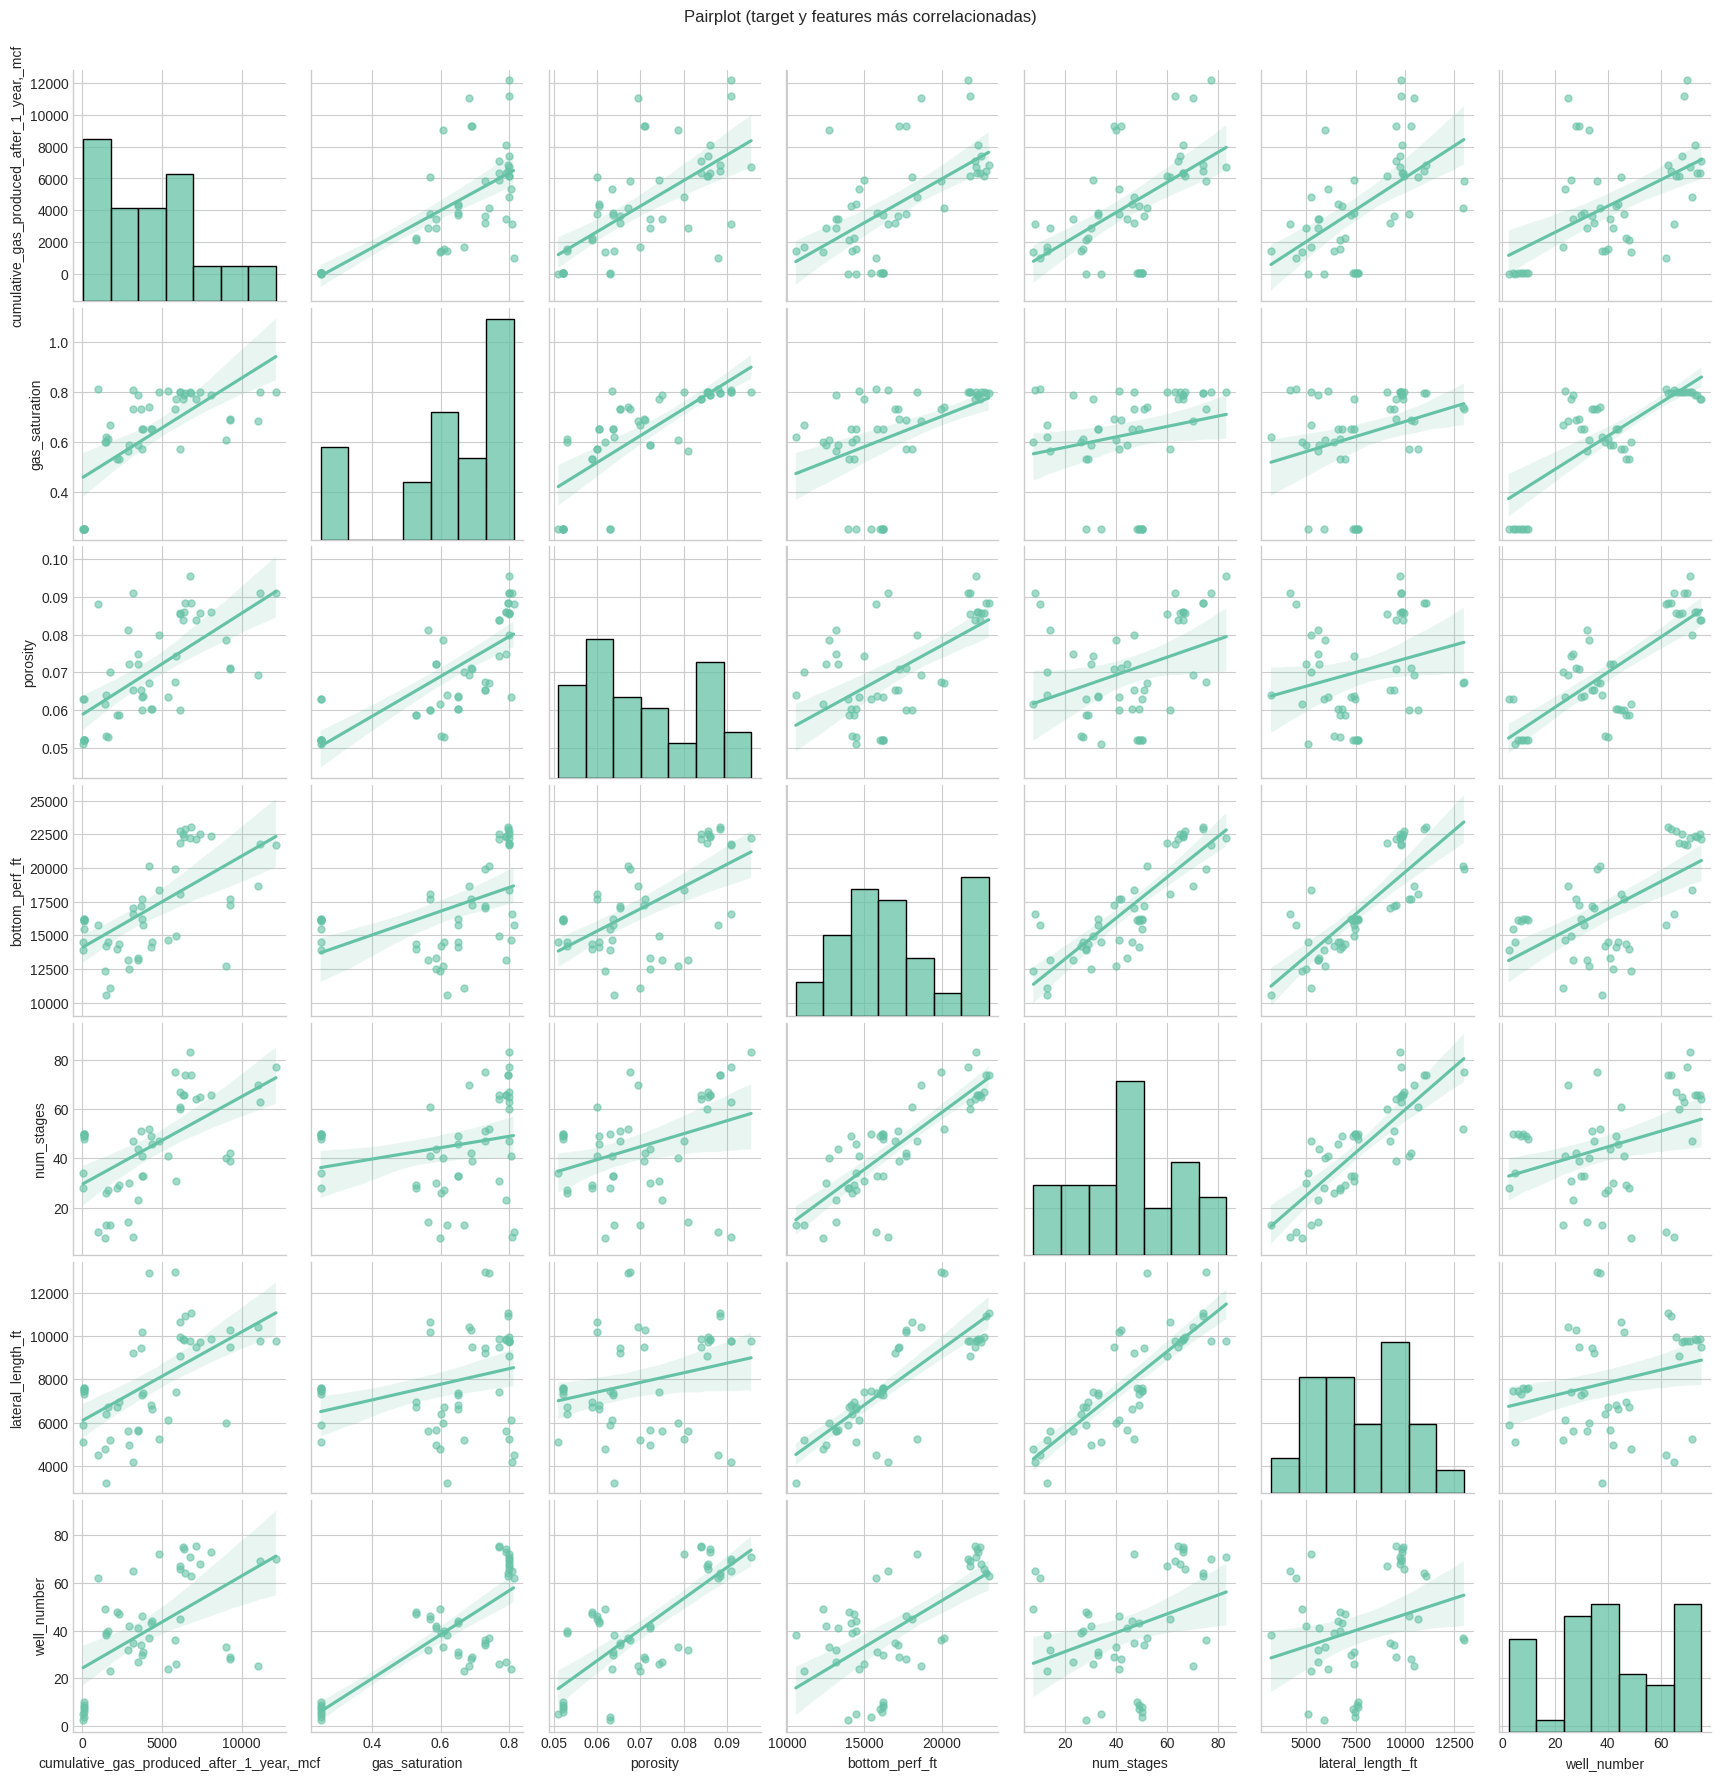

In [27]:
# ============================================
# 11) Relación con la variable objetivo (si existe)
#     - asumiendo "cumulative_gas_produced_after_1_year,_mcf" como target
# ============================================
target = 'cumulative_gas_produced_after_1_year,_mcf'
if target in df.columns:
    # Recalcular las columnas numéricas después de la eliminación de 'oil_saturation'
    current_num_cols = df.select_dtypes(include=np.number).columns.tolist()
    # Recalcular la matriz de correlación en el DataFrame actual
    corr = df[current_num_cols].corr()

    # Pairplot reducido para variables top-correlacionadas con el target
    top_feats = (corr[target]
                 .abs()
                 .sort_values(ascending=False)
                 .head(7)  # target + 6 mejores
                 .index.tolist())
    if target not in top_feats:
        top_feats = [target] + top_feats[:6]

    print('\nTop variables correlacionadas con el target:')
    print(corr[target].sort_values(ascending=False).head(10))

    sns.pairplot(df[top_feats], kind='reg', plot_kws={'scatter_kws': {'s': 25, 'alpha': 0.6}})
    plt.suptitle('Pairplot (target y features más correlacionadas)', y=1.02)
    plt.show()